In [2]:
pip install prophet

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.4/14.4 MB 59.6 MB/s eta 0:00:00 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.5/94.5 kB 1.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 863.9/863.9 kB 13.9 MB/s eta 0:00:000:00:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
Note: you may need to restart the kernel to use updated packages.


16:46:07 - cmdstanpy - INFO - Chain [1] start processing
16:46:08 - cmdstanpy - INFO - Chain [1] done processing
/tmp/ipykernel_1018/3136813084.py:50: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from current font.
  plt.tight_layout()
/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


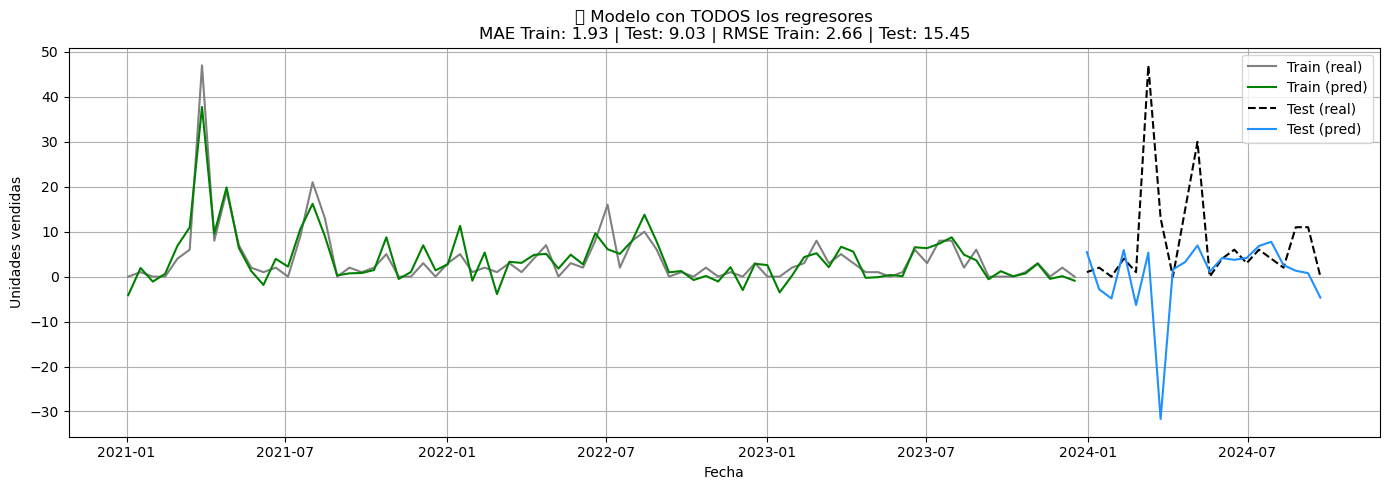

16:46:08 - cmdstanpy - INFO - Chain [1] start processing
16:46:09 - cmdstanpy - INFO - Chain [1] done processing
/tmp/ipykernel_1018/3136813084.py:50: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from current font.
  plt.tight_layout()
/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


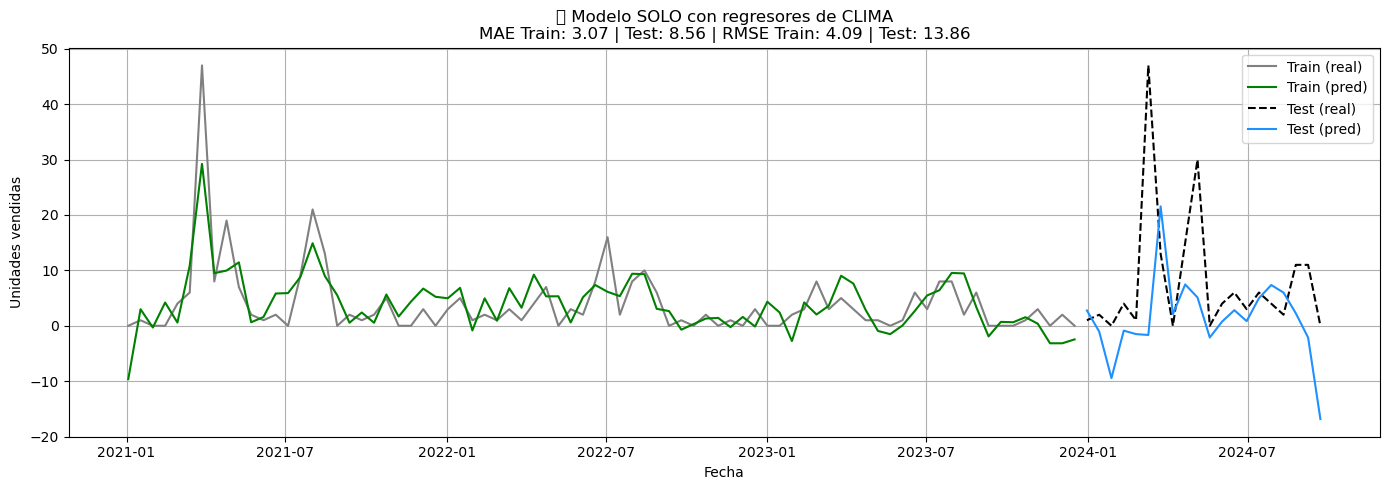

16:46:09 - cmdstanpy - INFO - Chain [1] start processing
16:46:10 - cmdstanpy - INFO - Chain [1] done processing
/tmp/ipykernel_1018/3136813084.py:50: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from current font.
  plt.tight_layout()
/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


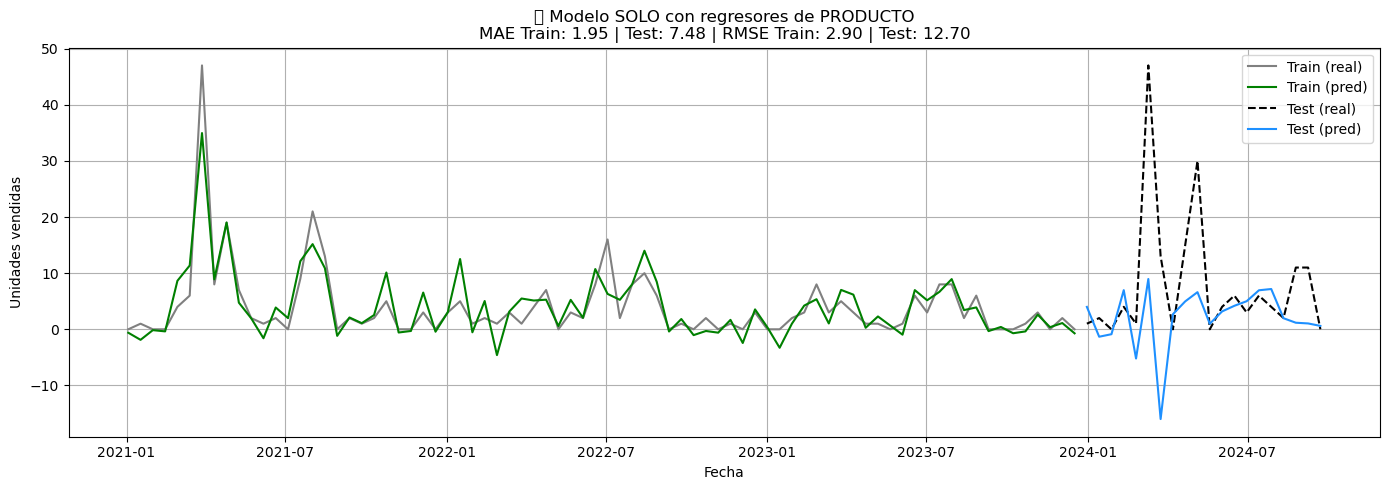

16:46:10 - cmdstanpy - INFO - Chain [1] start processing
16:46:10 - cmdstanpy - INFO - Chain [1] done processing
/tmp/ipykernel_1018/3136813084.py:50: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from current font.
  plt.tight_layout()
/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


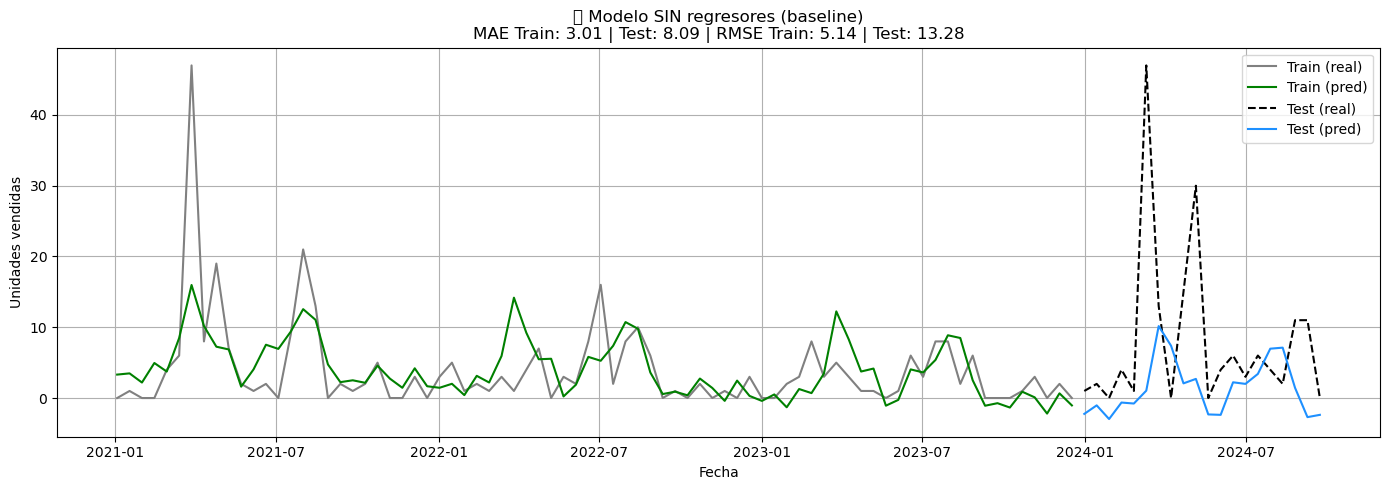

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Leer el archivo
df = pd.read_csv("data_input.csv")
df['fecha'] = pd.to_datetime(df['fecha'])
df.rename(columns={'fecha': 'ds', 'Unidades_y': 'y'}, inplace=True)

# Separar regresores
regresores_clima = [col for col in df.columns if col.startswith('conditions_')]
regresores_producto = [col for col in df.columns if col.startswith('CodigoArticulo_')]
todos_regresores = regresores_clima + regresores_producto

def run_prophet(df, regresores, titulo):
    columnas = ['ds', 'y'] + regresores
    df_model = df[columnas].copy()

    split_index = int(len(df_model) * 0.8)
    df_train = df_model.iloc[:split_index].reset_index(drop=True)
    df_test = df_model.iloc[split_index:].reset_index(drop=True)

    modelo = Prophet()
    for r in regresores:
        modelo.add_regressor(r)

    modelo.fit(df_train)

    forecast_train = modelo.predict(df_train[['ds'] + regresores])
    forecast_test = modelo.predict(df_test[['ds'] + regresores])

    # Métricas
    mae_train = mean_absolute_error(df_train['y'], forecast_train['yhat'])
    rmse_train = mean_squared_error(df_train['y'], forecast_train['yhat'], squared=False)
    mae_test = mean_absolute_error(df_test['y'], forecast_test['yhat'])
    rmse_test = mean_squared_error(df_test['y'], forecast_test['yhat'], squared=False)

    # Gráfico
    plt.figure(figsize=(14, 5))
    plt.plot(df_train['ds'], df_train['y'], label='Train (real)', color='gray')
    plt.plot(df_train['ds'], forecast_train['yhat'], label='Train (pred)', color='green')
    plt.plot(df_test['ds'], df_test['y'], label='Test (real)', color='black', linestyle='--')
    plt.plot(df_test['ds'], forecast_test['yhat'], label='Test (pred)', color='dodgerblue')
    plt.title(f"{titulo}\nMAE Train: {mae_train:.2f} | Test: {mae_test:.2f} | RMSE Train: {rmse_train:.2f} | Test: {rmse_test:.2f}")
    plt.xlabel("Fecha")
    plt.ylabel("Unidades vendidas")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Ejecutar los 4 escenarios
run_prophet(df, todos_regresores, "🔹 Modelo con TODOS los regresores")
run_prophet(df, regresores_clima, "🔹 Modelo SOLO con regresores de CLIMA")
run_prophet(df, regresores_producto, "🔹 Modelo SOLO con regresores de PRODUCTO")
run_prophet(df, [], "🔹 Modelo SIN regresores (baseline)")
